<h1 style="color: #25a890; font-size: 2.2em; margin-bottom: 5px; font-weight: 700;">Customer Segmentation | EDA</h1>

<p style="margin: 3px 0; font-size: 1.1em; font-weight: 600;">NOVA IMS <span style="font-weight: 300;">| Machine Learning II</span></p>
<p style="margin: 3px 0; font-size: 0.95em;"><strong">Professors</strong> Fernando Bação & Ivo Bernardo</p>


<br>
<table style="width: 100%; border-collapse: collapse; font-size: 1em;">
    <tr>
        <td style="padding: 4px 0; font-weight: 500;">Diogo Gonçalves</td>
        <td style="padding: 4px 0; text-align: right; font-family: monospace;">(20241817)</td>
    </tr>
    <tr>
        <td style="padding: 4px 0; font-weight: 500;">Gustavo Franco</td>
        <td style="padding: 4px 0; text-align: right; font-family: monospace;">(20241806)</td>
    </tr>
    <tr>
        <td style="padding: 4px 0; font-weight: 500;">Simão Costa</td>
        <td style="padding: 4px 0; text-align: right; font-family: monospace;">(20241772)</td>
    </tr>


    


<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;">Table of Contents</h3>
<div style="font-family: Arial, sans-serif; line-height: 1.8; margin-bottom: 30px; padding-left: 10px;">
    <ol style="margin-top: 0; padding-left: 20px;">
        <li><a href="#library-imports" style="color: #25a890; text-decoration: none; font-weight: 500;">Library Imports</a></li>
        <li><a href="#data-imports" style="color: #25a890; text-decoration: none; font-weight: 500;">Data Imports</a></li>
        <li>
            <a href="#data-cleaning" style="color: #25a890; text-decoration: none; font-weight: 500;">Data Exploration</a>
            <ul style="list-style-type: circle; padding-left: 20px; margin-top: 5px; margin-bottom: 5px;">
                <li><a href="#duplicates" style="color: #25a890; text-decoration: none;">Duplicates</a></li>
                <li><a href="#variable-consistency" style="color: #25a890; text-decoration: none;">Variable Consistency</a></li>
            </ul>
        </li>
        <li><a href="#correlation-between-variables" style="color: #25a890; text-decoration: none; font-weight: 500;">Correlation between variables</a></li>
    </ol>
</div>

<h2 style="color: #25a890; margin-bottom: 5px; font-weight: 700;">Library Imports</h2>

In [523]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from scipy.stats import f_oneway
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

<h2 style="color: #25a890; margin-bottom: 5px; font-weight: 700;">Data Import</h2>

In [524]:
pd.set_option('display.max_columns', None) # option to see all columns

cust_info = pd.read_csv('customer_info.csv', index_col=0)

cust_basket = pd.read_csv('customer_basket.csv', index_col=0)

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;"> Customer Information</h3>

In [525]:
cust_info.head()

,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
customer_id,,,,,,,,,,,,,,,,,,,,,,,,
3,Bsc. Crystal Kitchens,female,02/12/1970 01:36 PM,1.0,1.0,1.0,3.0,11731.0,4553.0,NaN,373.0,323.0,177.0,28.0,213.0,552.0,256.0,384.0,189.0,0.631599,2020.0,1.0,38.794428,-9.215739
4,Bsc. Glenda Bauman,female,11/13/1975 06:58 PM,1.0,0.0,0.0,2.0,13694.0,963.0,NaN,2012.0,533.0,95.0,43.0,15.0,1880.0,333.0,665.0,130.0,0.149890,2013.0,1.0,38.751711,-9.179611
5,Msc. Antonio Campbell,male,09/10/1971 10:07 AM,0.0,0.0,NaN,2.0,12407.0,0.0,11.0,555.0,101.0,118.0,1265.0,273.0,507.0,101.0,222.0,81.0,0.069126,2005.0,NaN,38.780678,-9.160656
7,John Kelling,male,10/23/1982 11:20 AM,0.0,0.0,2.0,1.0,7493.0,1105.0,18.0,84.0,757.0,1133.0,972.0,1083.0,485.0,1656.0,184.0,92.0,0.253609,2021.0,1.0,38.739548,-9.148679
8,Arthur Dematteo,male,08/04/1969 10:22 PM,0.0,0.0,3.0,1.0,9187.0,10841.0,17.0,380.0,592.0,718.0,1068.0,1015.0,297.0,1258.0,441.0,6.0,0.186569,2021.0,1.0,38.733071,-9.188188


In [526]:
cust_info.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33038 entries, 3 to 40000
Data columns (total 24 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   customer_name                            33038 non-null  object 
 1   customer_gender                          33038 non-null  object 
 2   customer_birthdate                       32873 non-null  object 
 3   kids_home                                32708 non-null  float64
 4   teens_home                               32708 non-null  float64
 5   number_complaints                        32377 non-null  float64
 6   distinct_stores_visited                  32708 non-null  float64
 7   lifetime_spend_groceries                 33038 non-null  float64
 8   lifetime_spend_electronics               32377 non-null  float64
 9   typical_hour                             32377 non-null  float64
 10  lifetime_spend_vegetables                32377 non-

In [527]:
cust_info.describe()

,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
count,32708.000000,32708.000000,32377.000000,32708.000000,33038.000000,32377.000000,32377.000000,32377.000000,33038.000000,32708.000000,32377.000000,32047.000000,32708.00000,32377.000000,32377.000000,33038.000000,32708.000000,33038.000000,19932.0,33038.000000,33038.000000
mean,1.116118,0.898893,0.930846,3.167941,16306.227798,2763.080088,12.659388,727.223801,464.352776,622.144185,723.721716,608.781228,820.34646,373.900917,336.217099,148.914644,0.318866,2015.311853,1.0,38.749694,-9.154549
std,1.150186,0.962924,0.894658,1.674114,11985.903518,3453.191495,4.854708,654.633087,275.767976,517.744320,483.022782,497.068874,608.31732,460.782042,160.234980,105.922907,0.283638,5.032196,0.0,0.022498,0.028581
min,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,-1.274940,1993.000000,1.0,38.687987,-9.232989
25%,0.000000,0.000000,0.000000,2.000000,8647.000000,579.000000,8.000000,224.000000,241.000000,201.000000,343.000000,171.000000,362.00000,125.000000,225.000000,67.000000,0.122359,2012.000000,1.0,38.734079,-9.173732
50%,1.000000,1.000000,1.000000,3.000000,13002.500000,1470.000000,12.000000,471.000000,421.000000,483.000000,729.000000,511.000000,686.00000,223.000000,327.000000,123.000000,0.239449,2015.000000,1.0,38.748286,-9.156689
75%,1.000000,1.000000,1.000000,4.000000,20807.000000,3745.000000,16.000000,1074.000000,640.000000,891.250000,1010.000000,923.000000,1120.00000,374.000000,435.000000,210.000000,0.469390,2019.000000,1.0,38.765779,-9.139608
max,8.000000,6.000000,7.000000,10.000000,104670.000000,35299.000000,23.000000,3337.000000,2180.000000,3704.000000,3052.000000,3172.000000,3482.00000,3936.000000,1224.000000,600.000000,1.000000,2029.000000,1.0,38.823693,-9.035697


<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;"> Customer Basket</h3>

In [528]:
cust_basket.head()

,list_of_goods,customer_id
invoice_id,,
3700630,"['chicken', 'rice', 'pepper', 'whole wheat ric...",12912
10242376,"['low fat yogurt', 'tomatoes', 'pepper', 'aspa...",22853
91550,"['cake', 'tomatoes', 'pancakes', 'iPad', 'fina...",19
3137503,"['cereals', 'megaman zero', 'final fantasy XIX...",10995
7165061,"['rice', 'frozen smoothie', 'black tea', 'tea'...",27807


In [529]:
cust_basket.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 3700630 to 12236507
Data columns (total 2 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   list_of_goods  100000 non-null  object
 1   customer_id    100000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 2.3+ MB


In [530]:
cust_basket.describe()

,customer_id
count,100000.000000
mean,20034.595410
std,11546.142217
min,3.000000
25%,10026.000000
50%,20018.000000
75%,30047.000000
max,40000.000000


<h2 style="color: #25a890; margin-bottom: 5px; font-weight: 700;">Data Cleaning</h2>

<h3 style="color: #25a890; margin-bottom: 5px; font-weight: 700;">Duplicates</h3>

Checking for duplicates (rows 100% equal) in both datasets.

In [531]:
cust_info.duplicated().sum()

np.int64(0)

In [532]:
cust_basket.duplicated().sum()

np.int64(0)

We found 0 duplicate rows in both datasets.

<h3 style="color: #25a890; margin-bottom: 5px; font-weight: 700;">Variable Consistency</h3>

<h4 style="color: #25a890; margin-bottom: 5px; font-weight: 700;"><code style="color: #25a890;">customer_name</code></h4>

- string
- no missing values
- 495 duplicates (1.5%) - can be true duplicates, as 2 customers might have same names

In [533]:
cust_info['customer_name'].head(10)

customer_id
3     Bsc. Crystal Kitchens
4        Bsc. Glenda Bauman
5     Msc. Antonio Campbell
7              John Kelling
8           Arthur Dematteo
9        Msc. Nadine Garcia
10       Phd. Franklin Alba
11      Bsc. Robert Hansing
12     Phd. Dorothy Pacheco
14      Msc. Arron Burgener
Name: customer_name, dtype: object

In [534]:
variable = 'customer_name'
print("Duplicates: " + str(cust_info[variable].duplicated().sum()))
percentage = cust_info[variable].duplicated().sum() / len(cust_info) * 100
print("Duplicates Percentage: " + percentage.round(2).astype(str) + "%")
print(" ")
print("Missing Values: " + str(cust_info[variable].isnull().sum()))
percentage = cust_info[variable].isnull().sum() / len(cust_info) * 100
print("Missing Values Percentage: " + percentage.round(2).astype(str) + "%")

Duplicates: 495
Duplicates Percentage: 1.5%
 
Missing Values: 0
Missing Values Percentage: 0.0%


<h4 style="color: #25a890; margin-bottom: 5px; font-weight: 700;"><code style="color: #25a890;">customer_gender</code></h4>


<p style="color: #25a890;">- string, of binary nature - female or male</p>
<p style="color: #25a890;">- no missing values</p>
<p style="color: #25a890;">- roughly well distributed between 2 classes</p>

In [535]:
cust_info['customer_gender'].value_counts()

customer_gender
female    16577
male      16461
Name: count, dtype: int64

In [536]:
variable = 'customer_gender'

print("Missing Values:" + str(cust_info[variable].isnull().sum()))
percentage = cust_info[variable].isnull().sum() / len(cust_info) * 100
print("Missing Values Percentage: " + percentage.round(2).astype(str) + "%")

Missing Values:0
Missing Values Percentage: 0.0%


<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;"> Distribution</h3>

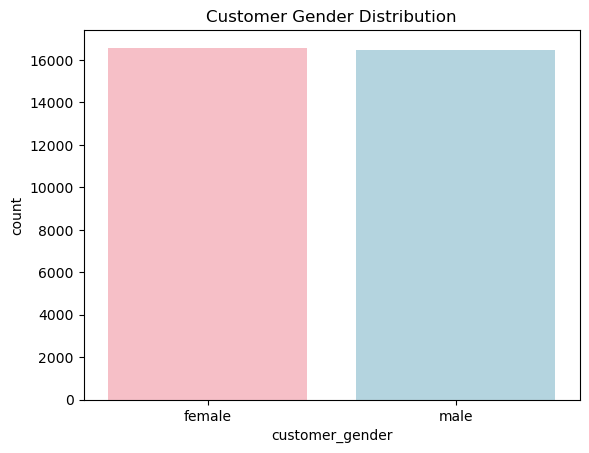

In [537]:
palette = {'male': 'lightblue', 'female': 'lightpink'}

sns.countplot(data=cust_info, x='customer_gender', palette=palette)
plt.title('Customer Gender Distribution')
plt.show()

<h4 style="color: #25a890; margin-bottom: 5px; font-weight: 700;"><code style="color: #25a890;">customer_birthdate</code></h4>


<p style="color: #25a890;">- datetime - year, month, day, hour, minute</p>
<p style="color: #25a890;">- 165 (0,5%) of missing values</p>
<p style="color: #25a890;">- years between 1940 and 2002</p>

In [538]:
variable = 'customer_birthdate'
print("Missing Values: " + str(cust_info[variable].isnull().sum()))
percentage = cust_info[variable].isnull().sum() / len(cust_info) * 100
print("Missing Values Percentage: " + percentage.round(2).astype(str) + "%")

Missing Values: 165
Missing Values Percentage: 0.5%


In [539]:
pd.to_datetime(cust_info['customer_birthdate']).dt.year.describe()

count    32873.000000
mean      1970.879749
std         18.064552
min       1940.000000
25%       1955.000000
50%       1971.000000
75%       1987.000000
max       2002.000000
Name: customer_birthdate, dtype: float64

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;"> Distribution</h3>

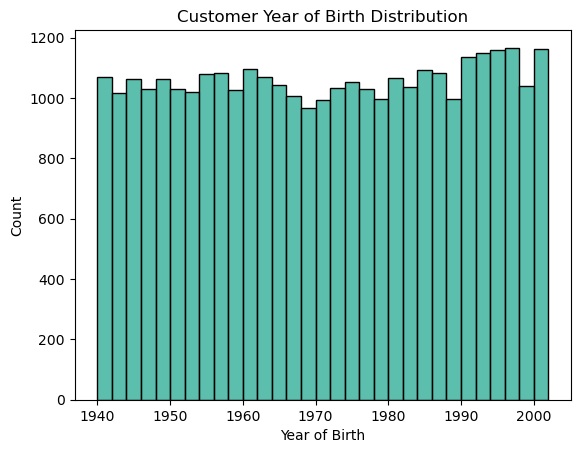

In [540]:
customer_year = pd.to_datetime(cust_info['customer_birthdate']).dt.year

sns.histplot(data=customer_year, color = '#25a890', bins=31)
plt.title('Customer Year of Birth Distribution')
plt.xlabel('Year of Birth')
plt.ylabel('Count')
plt.show()

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;">Outliers</h3>

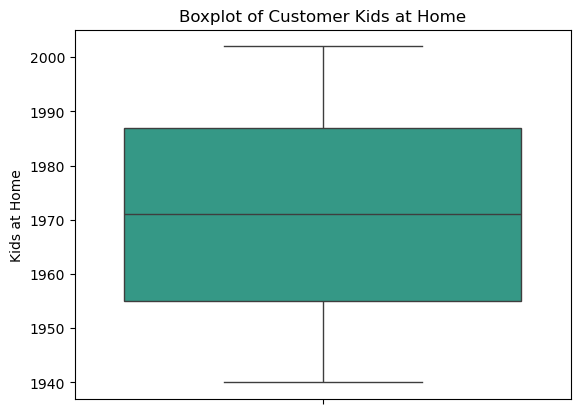

In [541]:
sns.boxplot(y=customer_year, color = '#25a890')
plt.title('Boxplot of Customer Kids at Home')
plt.ylabel('Kids at Home')
plt.show()

<h4 style="color: #25a890; margin-bottom: 5px; font-weight: 700;"><code style="color: #25a890;">kids_home</code></h4>


<p style="color: #25a890;">- integer between 0 and 8</p>
<p style="color: #25a890;">- 330 (1%) of missing values</p>

In [542]:
variable = 'kids_home'
print("Missing Values: " + str(cust_info[variable].isnull().sum()))
percentage = cust_info[variable].isnull().sum() / len(cust_info) * 100
print("Missing Values Percentage: " + percentage.round(2).astype(str) + "%")

Missing Values: 330
Missing Values Percentage: 1.0%


In [543]:
cust_info['kids_home'].describe()

count    32708.000000
mean         1.116118
std          1.150186
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          8.000000
Name: kids_home, dtype: float64

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;"> Distribution</h3>

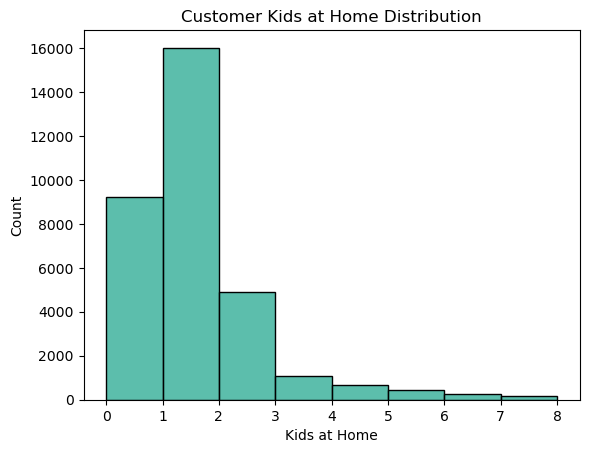

In [544]:
sns.histplot(data = cust_info['kids_home'],color = '#25a890', bins=8)
plt.title('Customer Kids at Home Distribution')
plt.xlabel('Kids at Home')
plt.ylabel('Count')
plt.show()

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;">Outliers</h3>

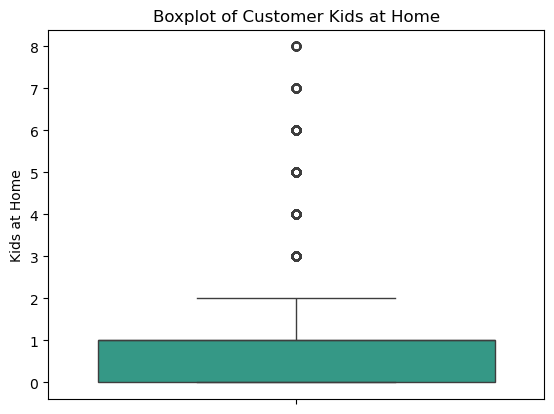

In [545]:
sns.boxplot(y=cust_info['kids_home'], color = '#25a890')
plt.title('Boxplot of Customer Kids at Home')
plt.ylabel('Kids at Home')
plt.show()

<h4 style="color: #25a890; margin-bottom: 5px; font-weight: 700;"><code style="color: #25a890;">kids_home</code></h4>

<p style="color: #25a890;">- integer between 0 and 6</p>
<p style="color: #25a890;">- 330 (1%) of missing values</p>

In [546]:
variable = 'teens_home'
print("Missing Values: " + str(cust_info[variable].isnull().sum()))
percentage = cust_info[variable].isnull().sum() / len(cust_info) * 100
print("Missing Values Percentage: " + percentage.round(2).astype(str) + "%")

Missing Values: 330
Missing Values Percentage: 1.0%


In [547]:
cust_info['teens_home'].describe()

count    32708.000000
mean         0.898893
std          0.962924
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          6.000000
Name: teens_home, dtype: float64

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;"> Distribution</h3>

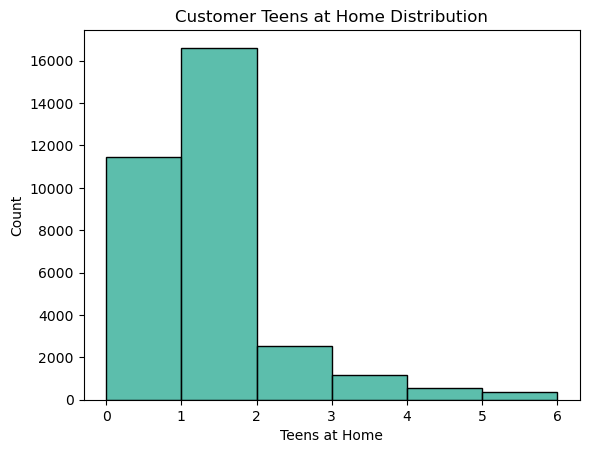

In [548]:
sns.histplot(data = cust_info['teens_home'], color = '#25a890', bins=6)
plt.title('Customer Teens at Home Distribution')
plt.xlabel('Teens at Home')
plt.ylabel('Count')
plt.show()

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;">Outliers</h3>

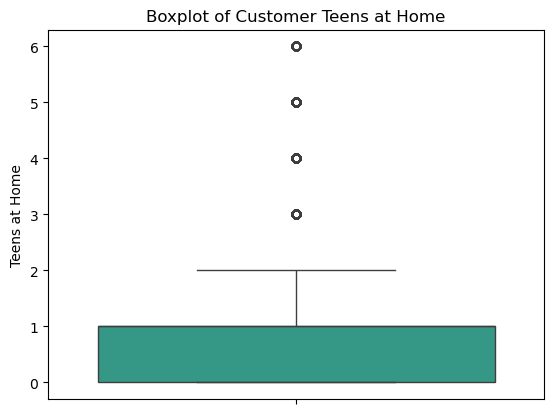

In [549]:
sns.boxplot(y=cust_info['teens_home'], color = '#25a890')
plt.title('Boxplot of Customer Teens at Home')
plt.ylabel('Teens at Home')
plt.show()

<h4 style="color: #25a890; margin-bottom: 5px; font-weight: 700;"><code style="color: #25a890;">number_complaints</code></h4>


<p style="color: #25a890;">- integer between 0 and 7</p>
<p style="color: #25a890;">- 661 (2%) of missing values</p>

In [550]:
variable = 'number_complaints'
print("Missing Values: " + str(cust_info[variable].isnull().sum()))
percentage = cust_info[variable].isnull().sum() / len(cust_info) * 100
print("Missing Values Percentage: " + percentage.round(2).astype(str) + "%")

Missing Values: 661
Missing Values Percentage: 2.0%


In [551]:
cust_info['number_complaints'].describe()

count    32377.000000
mean         0.930846
std          0.894658
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          7.000000
Name: number_complaints, dtype: float64

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;"> Distribution</h3>

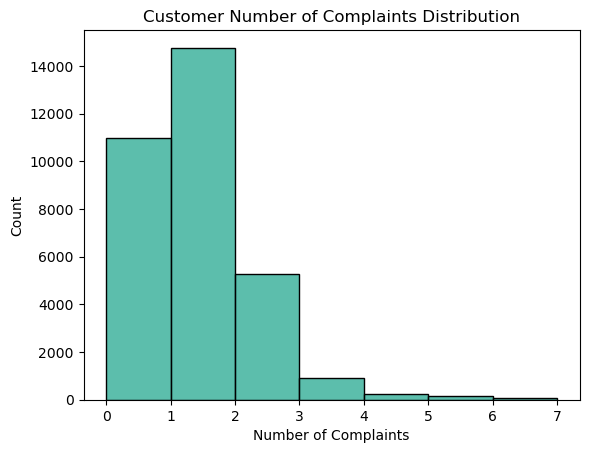

In [552]:
sns.histplot(data = cust_info['number_complaints'], color = '#25a890', bins=7)
plt.title('Customer Number of Complaints Distribution')
plt.xlabel('Number of Complaints')
plt.ylabel('Count')
plt.show()

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;">Outliers</h3>

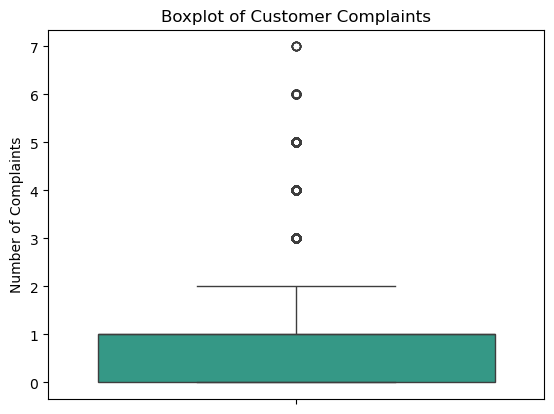

In [553]:
sns.boxplot(y=cust_info['number_complaints'], color = '#25a890')
plt.title('Boxplot of Customer Complaints')
plt.ylabel('Number of Complaints')
plt.show()

<h4 style="color: #25a890; margin-bottom: 5px; font-weight: 700;"><code style="color: #25a890;">distinct_stores_visited</code></h4>

<p style="color: #25a890;">- integer between 0 and 10</p>
<p style="color: #25a890;">- 330 (1%) of missing values</p>

In [554]:
variable = 'distinct_stores_visited'
print("Missing Values: " + str(cust_info[variable].isnull().sum()))
percentage = cust_info[variable].isnull().sum() / len(cust_info) * 100
print("Missing Values Percentage: " + percentage.round(2).astype(str) + "%")

Missing Values: 330
Missing Values Percentage: 1.0%


In [555]:
cust_info['distinct_stores_visited'].describe()

count    32708.000000
mean         3.167941
std          1.674114
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max         10.000000
Name: distinct_stores_visited, dtype: float64

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;"> Distribution</h3>

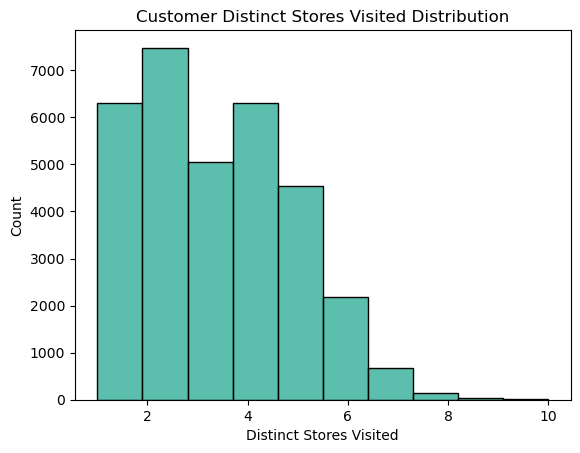

In [556]:
sns.histplot(data = cust_info['distinct_stores_visited'], color = '#25a890', bins=10)
plt.title('Customer Distinct Stores Visited Distribution')
plt.xlabel('Distinct Stores Visited')
plt.ylabel('Count')
plt.show()

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;">Outliers</h3>

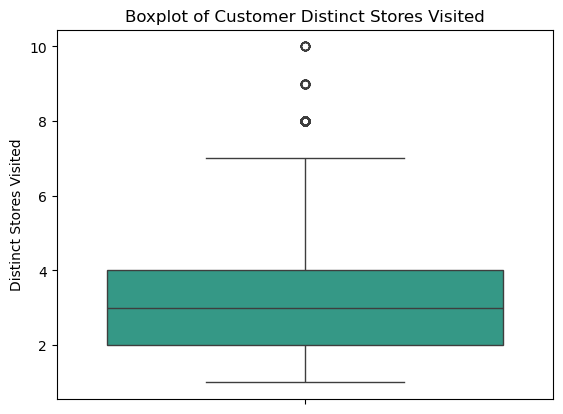

In [557]:
sns.boxplot(y=cust_info['distinct_stores_visited'], color = '#25a890')
plt.title('Boxplot of Customer Distinct Stores Visited')
plt.ylabel('Distinct Stores Visited')
plt.show()

<h4 style="color: #25a890; margin-bottom: 5px; font-weight: 700;"><code style="color: #25a890;">lifetime_spend_groceries</code></h4>

<p style="color: #25a890;">- Amount of money</p>
<p style="color: #25a890;">- No missing values</p>

In [558]:
variable = 'lifetime_spend_groceries'
print("Missing Values: " + str(cust_info[variable].isnull().sum()))
percentage = cust_info[variable].isnull().sum() / len(cust_info) * 100
print("Missing Values Percentage: " + percentage.round(2).astype(str) + "%")

Missing Values: 0
Missing Values Percentage: 0.0%


In [559]:
cust_info['lifetime_spend_groceries'].describe()

count     33038.000000
mean      16306.227798
std       11985.903518
min           0.000000
25%        8647.000000
50%       13002.500000
75%       20807.000000
max      104670.000000
Name: lifetime_spend_groceries, dtype: float64

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;"> Distribution</h3>

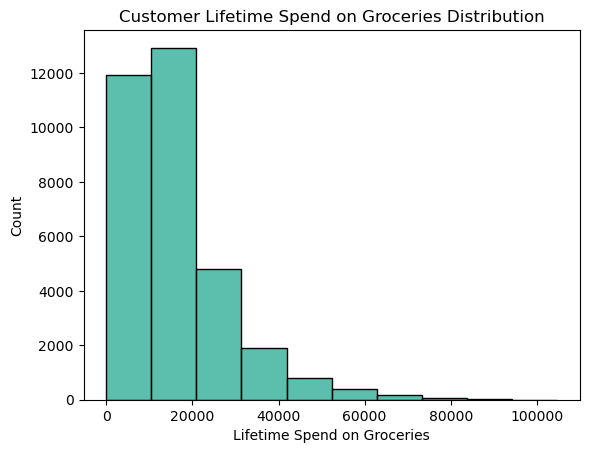

In [560]:
sns.histplot(data = cust_info['lifetime_spend_groceries'], color = '#25a890', bins=10)
plt.title('Customer Lifetime Spend on Groceries Distribution')
plt.xlabel('Lifetime Spend on Groceries')
plt.ylabel('Count')
plt.show()

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;">Outliers</h3>

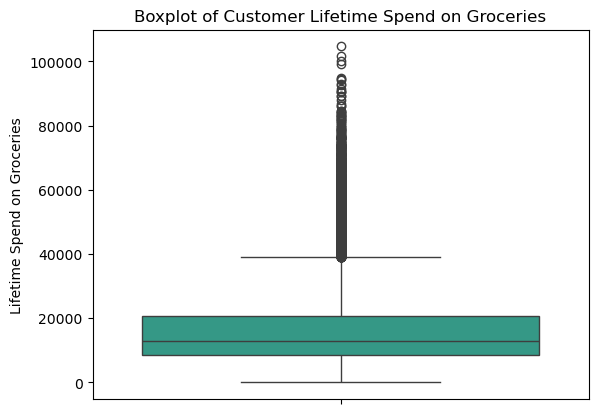

In [561]:
sns.boxplot(y=cust_info['lifetime_spend_groceries'], color = '#25a890')
plt.title('Boxplot of Customer Lifetime Spend on Groceries')
plt.ylabel('Lifetime Spend on Groceries')
plt.show()

<h4 style="color: #25a890; margin-bottom: 5px; font-weight: 700;"><code style="color: #25a890;">lifetime_spend_electronics</code></h4>

<p style="color: #25a890;">- Amount of money</p>
<p style="color: #25a890;">- 661 (2%) of missing values</p>

In [562]:
variable = 'lifetime_spend_electronics'
print("Missing Values: " + str(cust_info[variable].isnull().sum()))
percentage = cust_info[variable].isnull().sum() / len(cust_info) * 100
print("Missing Values Percentage: " + percentage.round(2).astype(str) + "%")

Missing Values: 661
Missing Values Percentage: 2.0%


In [563]:
cust_info['lifetime_spend_electronics'].describe()

count    32377.000000
mean      2763.080088
std       3453.191495
min          0.000000
25%        579.000000
50%       1470.000000
75%       3745.000000
max      35299.000000
Name: lifetime_spend_electronics, dtype: float64

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;"> Distribution</h3>

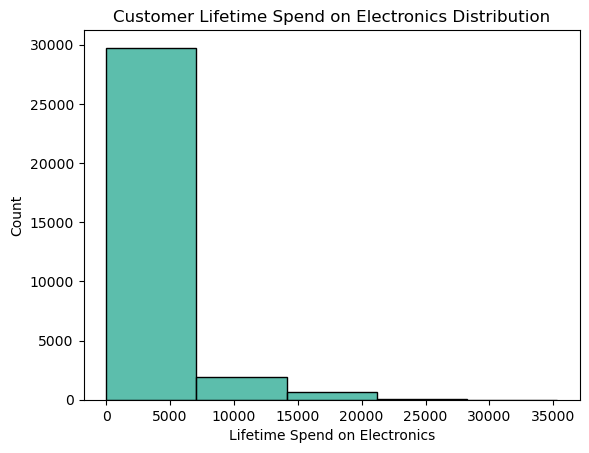

In [564]:
sns.histplot(data = cust_info['lifetime_spend_electronics'], color = '#25a890',bins=5)
plt.title('Customer Lifetime Spend on Electronics Distribution')
plt.xlabel('Lifetime Spend on Electronics')
plt.ylabel('Count')
plt.show()

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;">Outliers</h3>

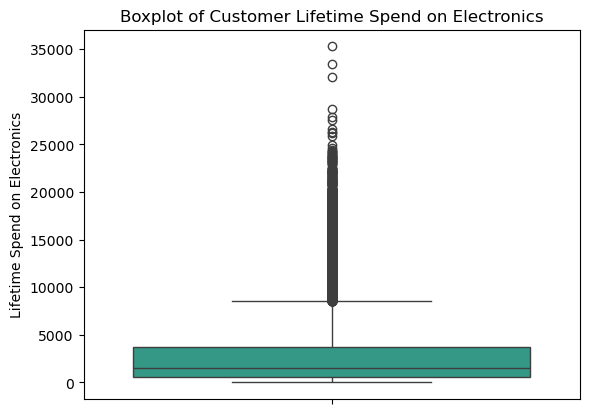

In [565]:
sns.boxplot(y=cust_info['lifetime_spend_electronics'], color = '#25a890')
plt.title('Boxplot of Customer Lifetime Spend on Electronics')
plt.ylabel('Lifetime Spend on Electronics')
plt.show()

<h4 style="color: #25a890; margin-bottom: 5px; font-weight: 700;"><code style="color: #25a890;">typical_hour</code></h4>

<p style="color: #25a890;">- Hour of the day</p>
<p style="color: #25a890;">- 661 (2%) of missing values</p>

In [566]:
variable = 'typical_hour'
print("Missing Values: " + str(cust_info[variable].isnull().sum()))
percentage = cust_info[variable].isnull().sum() / len(cust_info) * 100
print("Missing Values Percentage: " + percentage.round(2).astype(str) + "%")

Missing Values: 661
Missing Values Percentage: 2.0%


In [567]:
cust_info['typical_hour'].describe()

count    32377.000000
mean        12.659388
std          4.854708
min          6.000000
25%          8.000000
50%         12.000000
75%         16.000000
max         23.000000
Name: typical_hour, dtype: float64

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;"> Distribution</h3>

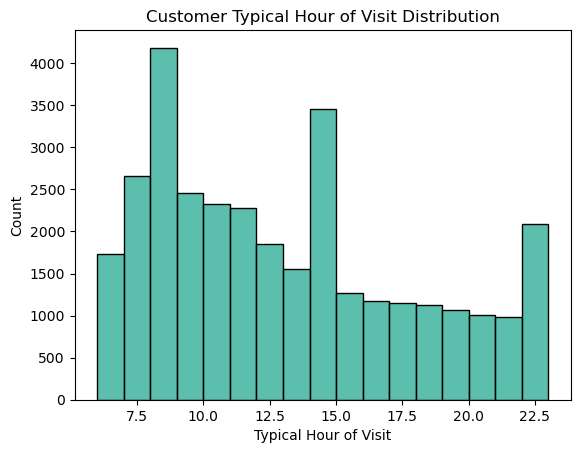

In [568]:
sns.histplot(data = cust_info['typical_hour'], color = '#25a890', bins=17)
plt.title('Customer Typical Hour of Visit Distribution')
plt.xlabel('Typical Hour of Visit')
plt.ylabel('Count')
plt.show()

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;">Outliers</h3>

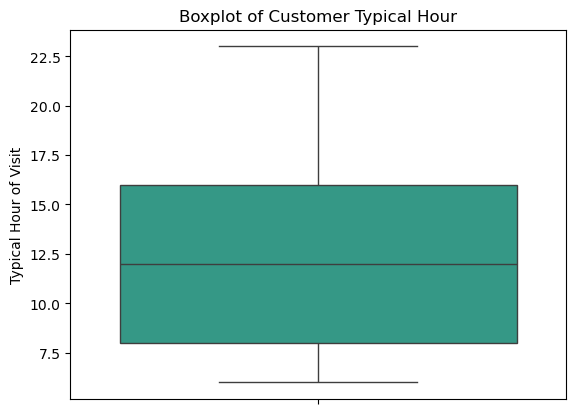

In [569]:
sns.boxplot(y=cust_info['typical_hour'], color = '#25a890')
plt.title('Boxplot of Customer Typical Hour')
plt.ylabel('Typical Hour of Visit')
plt.show()

<h4 style="color: #25a890; margin-bottom: 5px; font-weight: 700;"><code style="color: #25a890;">lifetime_spend_vegetables</code></h4>

<p style="color: #25a890;">- Amount of money</p>
<p style="color: #25a890;">- 661 (2%) of missing values</p>

In [570]:
variable = 'lifetime_spend_vegetables'
print("Missing Values: " + str(cust_info[variable].isnull().sum()))
percentage = cust_info[variable].isnull().sum() / len(cust_info) * 100
print("Missing Values Percentage: " + percentage.round(2).astype(str) + "%")

Missing Values: 661
Missing Values Percentage: 2.0%


In [571]:
cust_info['lifetime_spend_vegetables'].describe()

count    32377.000000
mean       727.223801
std        654.633087
min          0.000000
25%        224.000000
50%        471.000000
75%       1074.000000
max       3337.000000
Name: lifetime_spend_vegetables, dtype: float64

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;"> Distribution</h3>

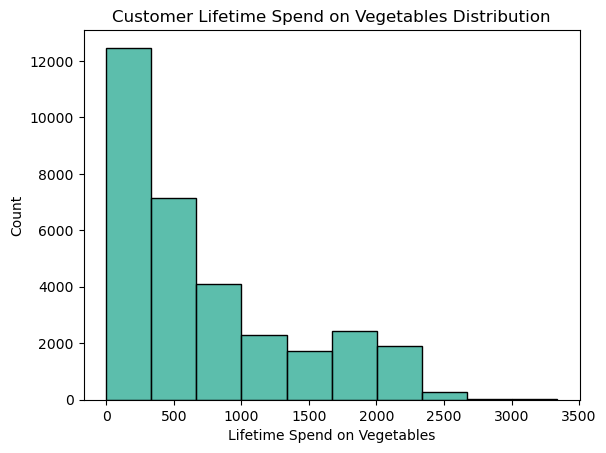

In [572]:
sns.histplot(data = cust_info['lifetime_spend_vegetables'], color = '#25a890', bins=10)
plt.title('Customer Lifetime Spend on Vegetables Distribution')
plt.xlabel('Lifetime Spend on Vegetables')
plt.ylabel('Count')
plt.show()

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;">Outliers</h3>

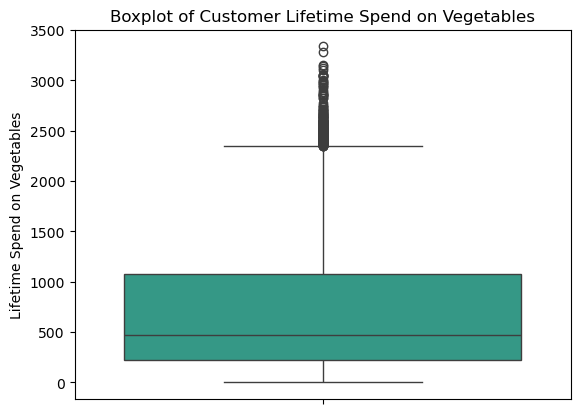

In [573]:
sns.boxplot(y=cust_info['lifetime_spend_vegetables'] , color = '#25a890')
plt.title('Boxplot of Customer Lifetime Spend on Vegetables')
plt.ylabel('Lifetime Spend on Vegetables')
plt.show()

<h4 style="color: #25a890; margin-bottom: 5px; font-weight: 700;"><code style="color: #25a890;">lifetime_spend_nonalcohol_drinks</code></h4>

<p style="color: #25a890;">- Amount of money</p>
<p style="color: #25a890;">- No missing values</p>

In [574]:
variable = 'lifetime_spend_nonalcohol_drinks'
print("Missing Values: " + str(cust_info[variable].isnull().sum()))
percentage = cust_info[variable].isnull().sum() / len(cust_info) * 100
print("Missing Values Percentage: " + percentage.round(2).astype(str) + "%")

Missing Values: 0
Missing Values Percentage: 0.0%


In [575]:
cust_info['lifetime_spend_nonalcohol_drinks'].describe()

count    33038.000000
mean       464.352776
std        275.767976
min          0.000000
25%        241.000000
50%        421.000000
75%        640.000000
max       2180.000000
Name: lifetime_spend_nonalcohol_drinks, dtype: float64

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;"> Distribution</h3>

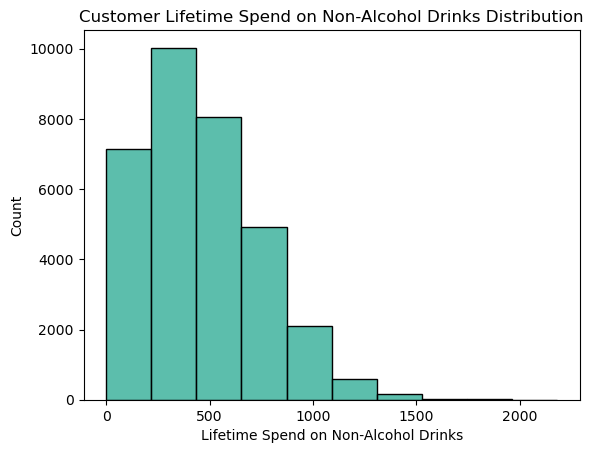

In [576]:
sns.histplot(data = cust_info['lifetime_spend_nonalcohol_drinks'], color = '#25a890', bins=10)
plt.title('Customer Lifetime Spend on Non-Alcohol Drinks Distribution')
plt.xlabel('Lifetime Spend on Non-Alcohol Drinks')
plt.ylabel('Count')
plt.show()

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;">Outliers</h3>

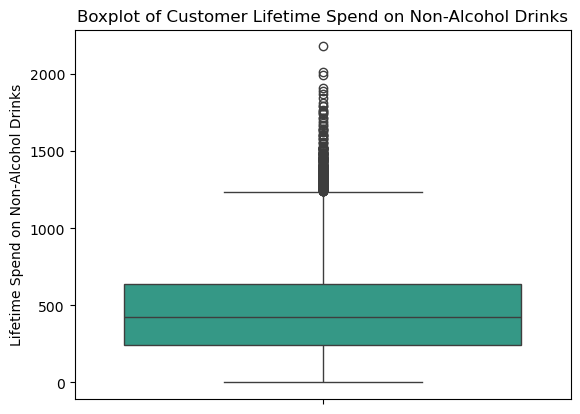

In [577]:
sns.boxplot(y=cust_info['lifetime_spend_nonalcohol_drinks'] , color = '#25a890')
plt.title('Boxplot of Customer Lifetime Spend on Non-Alcohol Drinks')
plt.ylabel('Lifetime Spend on Non-Alcohol Drinks')
plt.show()

<h4 style="color: #25a890; margin-bottom: 5px; font-weight: 700;"><code style="color: #25a890;">lifetime_spend_alcohol_drinks</code></h4>


<p style="color: #25a890;">- Amount of money</p>
<p style="color: #25a890;">- 330 (1%) of missing values</p>

In [578]:
variable = 'lifetime_spend_alcohol_drinks'
print("Missing Values: " + str(cust_info[variable].isnull().sum()))
percentage = cust_info[variable].isnull().sum() / len(cust_info) * 100
print("Missing Values Percentage: " + percentage.round(2).astype(str) + "%")

Missing Values: 330
Missing Values Percentage: 1.0%


In [579]:
cust_info['lifetime_spend_alcohol_drinks'].describe()

count    32708.000000
mean       622.144185
std        517.744320
min          0.000000
25%        201.000000
50%        483.000000
75%        891.250000
max       3704.000000
Name: lifetime_spend_alcohol_drinks, dtype: float64

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;"> Distribution</h3>

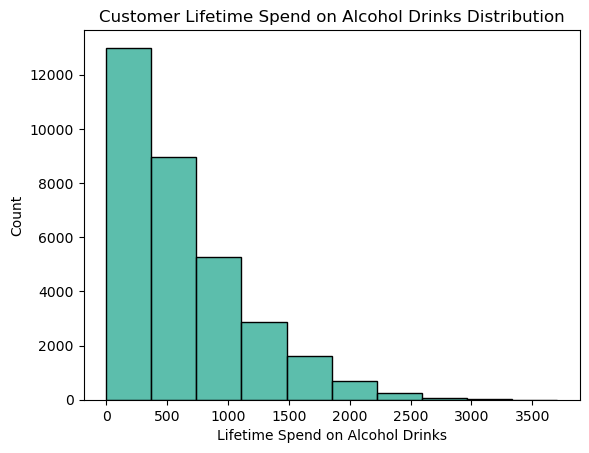

In [580]:
sns.histplot(data = cust_info['lifetime_spend_alcohol_drinks'], color = '#25a890', bins=10)
plt.title('Customer Lifetime Spend on Alcohol Drinks Distribution')
plt.xlabel('Lifetime Spend on Alcohol Drinks')
plt.ylabel('Count')
plt.show()

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;">Outliers</h3>

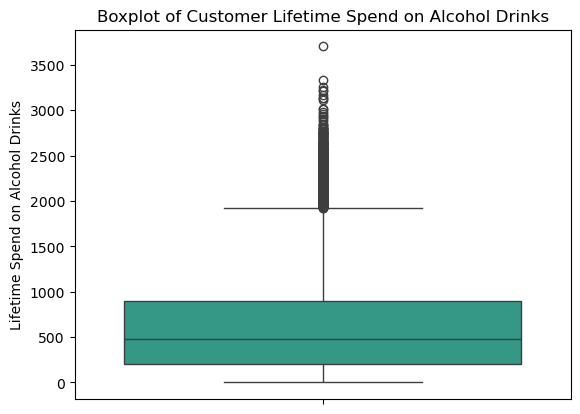

In [581]:
sns.boxplot(y=cust_info['lifetime_spend_alcohol_drinks'] , color = '#25a890')
plt.title('Boxplot of Customer Lifetime Spend on Alcohol Drinks')
plt.ylabel('Lifetime Spend on Alcohol Drinks')
plt.show()

<h4 style="color: #25a890; margin-bottom: 5px; font-weight: 700;"><code style="color: #25a890;">lifetime_spend_meat</code></h4>

<p style="color: #25a890;">- Amount of money</p>
<p style="color: #25a890;">- 661 (2%) of missing values</p>

In [582]:
variable = 'lifetime_spend_meat'
print("Missing Values: " + str(cust_info[variable].isnull().sum()))
percentage = cust_info[variable].isnull().sum() / len(cust_info) * 100
print("Missing Values Percentage: " + percentage.round(2).astype(str) + "%")

Missing Values: 661
Missing Values Percentage: 2.0%


In [583]:
cust_info['lifetime_spend_meat'].describe()

count    32377.000000
mean       723.721716
std        483.022782
min          0.000000
25%        343.000000
50%        729.000000
75%       1010.000000
max       3052.000000
Name: lifetime_spend_meat, dtype: float64

In [584]:
cust_info['lifetime_spend_meat'].head(10)

customer_id
3       28.0
4       43.0
5     1265.0
7      972.0
8     1068.0
9       27.0
10    1397.0
11     871.0
12     139.0
14     148.0
Name: lifetime_spend_meat, dtype: float64

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;"> Distribution</h3>

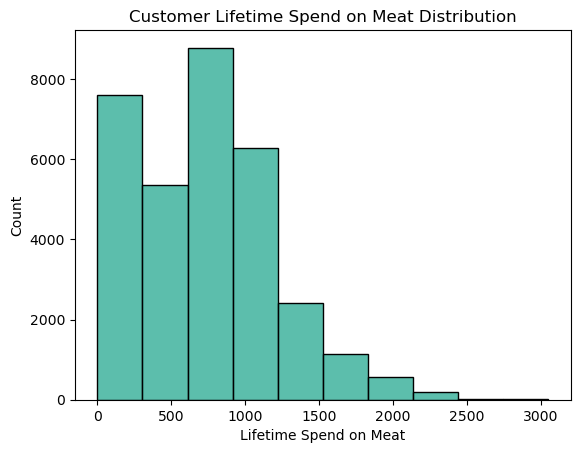

In [585]:
sns.histplot(data = cust_info['lifetime_spend_meat'], color = '#25a890', bins=10)
plt.title('Customer Lifetime Spend on Meat Distribution')
plt.xlabel('Lifetime Spend on Meat')
plt.ylabel('Count')
plt.show()

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;">Outliers</h3>

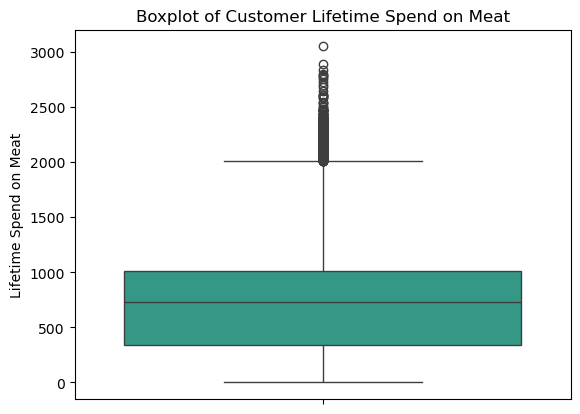

In [586]:
sns.boxplot(y=cust_info['lifetime_spend_meat'] , color = '#25a890')
plt.title('Boxplot of Customer Lifetime Spend on Meat')
plt.ylabel('Lifetime Spend on Meat')
plt.show()

<h4 style="color: #25a890; margin-bottom: 5px; font-weight: 700;"><code style="color: #25a890;">lifetime_spend_fish</code></h4>


<p style="color: #25a890;">- Amount of money</p>
<p style="color: #25a890;">- 991 (3%) of missing values</p>

In [587]:
variable = 'lifetime_spend_fish'
print("Missing Values: " + str(cust_info[variable].isnull().sum()))
percentage = cust_info[variable].isnull().sum() / len(cust_info) * 100
print("Missing Values Percentage: " + percentage.round(2).astype(str) + "%")

Missing Values: 991
Missing Values Percentage: 3.0%


In [588]:
cust_info['lifetime_spend_fish'].describe()

count    32047.000000
mean       608.781228
std        497.068874
min          0.000000
25%        171.000000
50%        511.000000
75%        923.000000
max       3172.000000
Name: lifetime_spend_fish, dtype: float64

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;"> Distribution</h3>

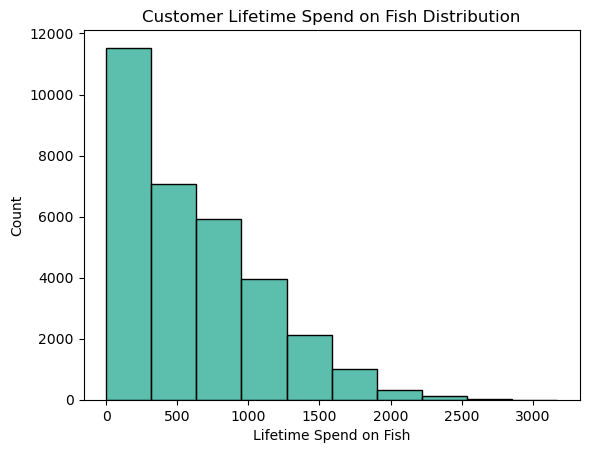

In [589]:
sns.histplot(data = cust_info['lifetime_spend_fish'], color = '#25a890', bins=10)
plt.title('Customer Lifetime Spend on Fish Distribution')
plt.xlabel('Lifetime Spend on Fish')
plt.ylabel('Count')
plt.show()

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;">Outliers</h3>

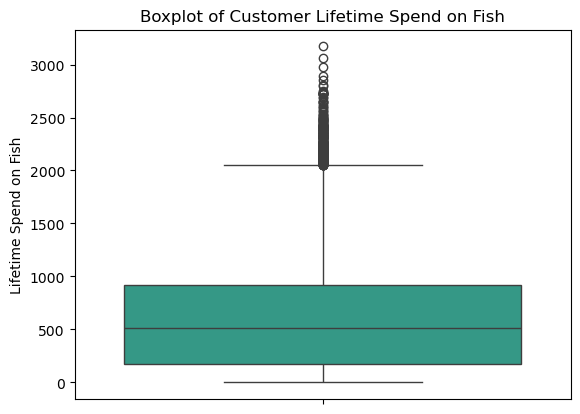

In [590]:
sns.boxplot(y=cust_info['lifetime_spend_fish'] , color = '#25a890')
plt.title('Boxplot of Customer Lifetime Spend on Fish')
plt.ylabel('Lifetime Spend on Fish')
plt.show()

<h4 style="color: #25a890; margin-bottom: 5px; font-weight: 700;"><code style="color: #25a890;">lifetime_spend_hygine</code></h4>

<p style="color: #25a890;">- Amount of money</p>
<p style="color: #25a890;">- 330 (1%) of missing values</p>

In [591]:
variable = 'lifetime_spend_hygiene'
print("Missing Values: " + str(cust_info[variable].isnull().sum()))
percentage = cust_info[variable].isnull().sum() / len(cust_info) * 100
print("Missing Values Percentage: " + percentage.round(2).astype(str) + "%")

Missing Values: 330
Missing Values Percentage: 1.0%


In [592]:
cust_info['lifetime_spend_hygiene'].describe()

count    32708.00000
mean       820.34646
std        608.31732
min          0.00000
25%        362.00000
50%        686.00000
75%       1120.00000
max       3482.00000
Name: lifetime_spend_hygiene, dtype: float64

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;"> Distribution</h3>

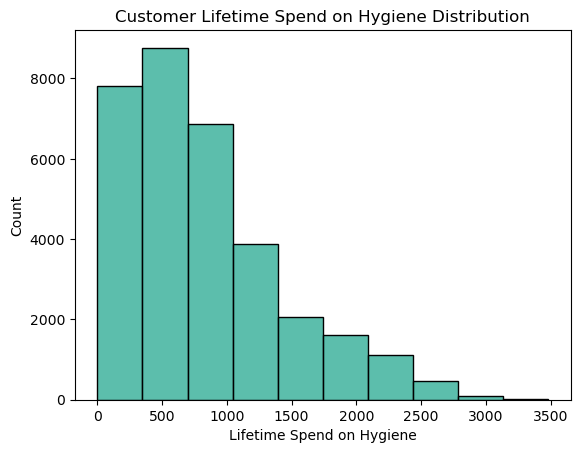

In [593]:
sns.histplot(data = cust_info['lifetime_spend_hygiene'], color = '#25a890', bins=10)
plt.title('Customer Lifetime Spend on Hygiene Distribution')
plt.xlabel('Lifetime Spend on Hygiene')
plt.ylabel('Count')
plt.show()

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;">Outliers</h3>

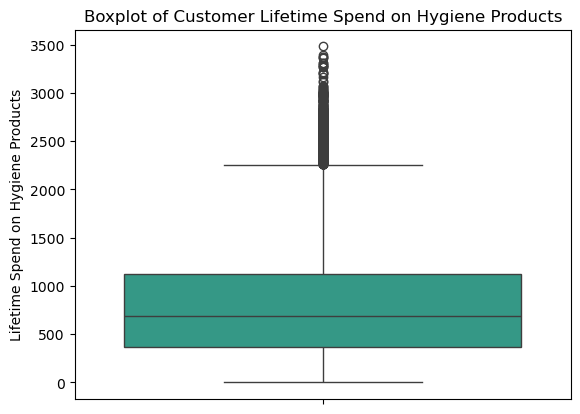

In [594]:
sns.boxplot(y=cust_info['lifetime_spend_hygiene'] , color = '#25a890')
plt.title('Boxplot of Customer Lifetime Spend on Hygiene Products')
plt.ylabel('Lifetime Spend on Hygiene Products')
plt.show()

<h4 style="color: #25a890; margin-bottom: 5px; font-weight: 700;"><code style="color: #25a890;">lifetime_spend_videogames</code></h4>


<p style="color: #25a890;">- Amount of money</p>
<p style="color: #25a890;">- 661 (2%) of missing values</p>

In [595]:
variable = 'lifetime_spend_videogames'
print("Missing Values: " + str(cust_info[variable].isnull().sum()))
percentage = cust_info[variable].isnull().sum() / len(cust_info) * 100
print("Missing Values Percentage: " + percentage.round(2).astype(str) + "%")

Missing Values: 661
Missing Values Percentage: 2.0%


In [596]:
cust_info['lifetime_spend_videogames'].describe()

count    32377.000000
mean       373.900917
std        460.782042
min          0.000000
25%        125.000000
50%        223.000000
75%        374.000000
max       3936.000000
Name: lifetime_spend_videogames, dtype: float64

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;"> Distribution</h3>

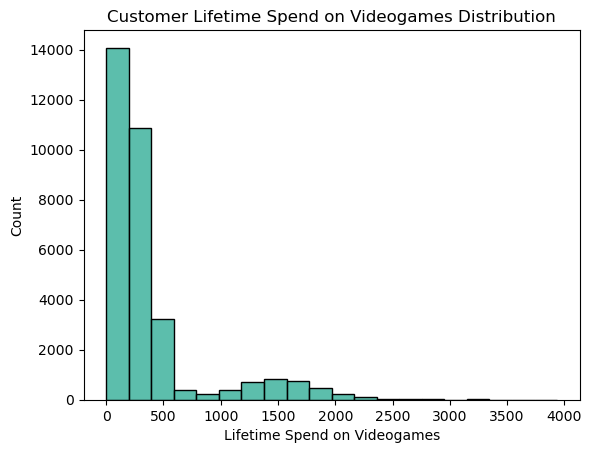

In [597]:
sns.histplot(data = cust_info['lifetime_spend_videogames'], color = '#25a890', bins=20)
plt.title('Customer Lifetime Spend on Videogames Distribution')
plt.xlabel('Lifetime Spend on Videogames')
plt.ylabel('Count')
plt.show()

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;">Outliers</h3>

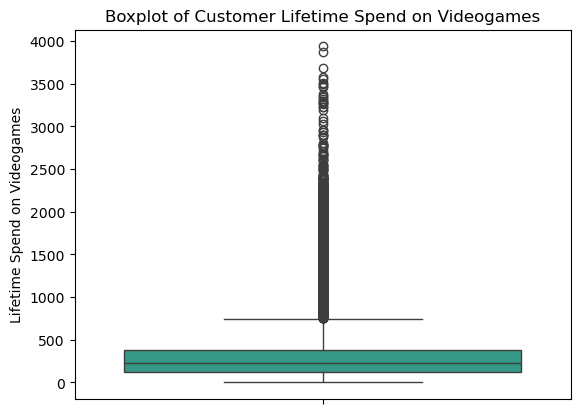

In [598]:
sns.boxplot(y=cust_info['lifetime_spend_videogames'] , color = '#25a890')
plt.title('Boxplot of Customer Lifetime Spend on Videogames')
plt.ylabel('Lifetime Spend on Videogames')
plt.show()

<h4 style="color: #25a890; margin-bottom: 5px; font-weight: 700;"><code style="color: #25a890;">lifetime_spend_petfood</code></h4>


<p style="color: #25a890;">- Amount of money</p>
<p style="color: #25a890;">- 661 (2%) of missing values</p>

In [599]:
variable = 'lifetime_spend_petfood'
print("Missing Values: " + str(cust_info[variable].isnull().sum()))
percentage = cust_info[variable].isnull().sum() / len(cust_info) * 100
print("Missing Values Percentage: " + percentage.round(2).astype(str) + "%")

Missing Values: 661
Missing Values Percentage: 2.0%


In [600]:
cust_info['lifetime_spend_petfood'].describe()

count    32377.000000
mean       336.217099
std        160.234980
min          0.000000
25%        225.000000
50%        327.000000
75%        435.000000
max       1224.000000
Name: lifetime_spend_petfood, dtype: float64

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;"> Distribution</h3>

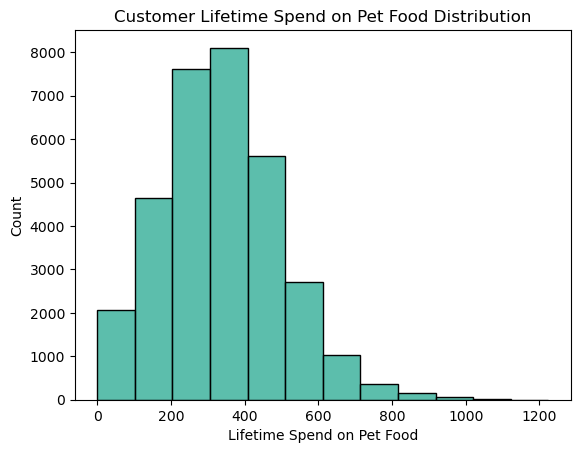

In [601]:
sns.histplot(data = cust_info['lifetime_spend_petfood'], color = '#25a890', bins=12)
plt.title('Customer Lifetime Spend on Pet Food Distribution')
plt.xlabel('Lifetime Spend on Pet Food')
plt.ylabel('Count')
plt.show()

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;">Outliers</h3>

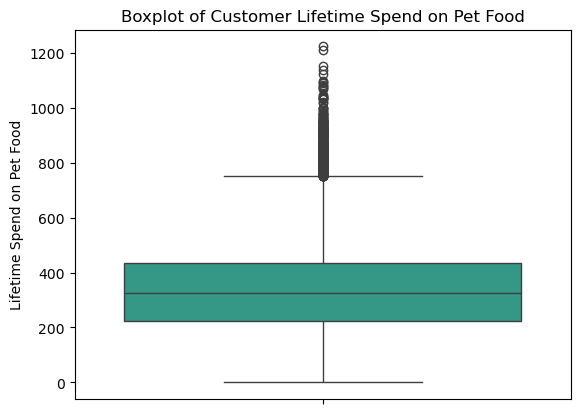

In [602]:
sns.boxplot(y=cust_info['lifetime_spend_petfood'], color = '#25a890')
plt.title('Boxplot of Customer Lifetime Spend on Pet Food')
plt.ylabel('Lifetime Spend on Pet Food')
plt.show()

<h4 style="color: #25a890; margin-bottom: 5px; font-weight: 700;"><code style="color: #25a890;">lifetime_total_distinct_products</code></h4>


<p style="color: #25a890;">- Amount of money</p>
<p style="color: #25a890;">- No missing values</p>

In [603]:
variable = 'lifetime_total_distinct_products'
print("Missing Values: " + str(cust_info[variable].isnull().sum()))
percentage = cust_info[variable].isnull().sum() / len(cust_info) * 100
print("Missing Values Percentage: " + percentage.round(2).astype(str) + "%")

Missing Values: 0
Missing Values Percentage: 0.0%


In [604]:
cust_info['lifetime_total_distinct_products'].describe()

count    33038.000000
mean       148.914644
std        105.922907
min          0.000000
25%         67.000000
50%        123.000000
75%        210.000000
max        600.000000
Name: lifetime_total_distinct_products, dtype: float64

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;"> Distribution</h3>

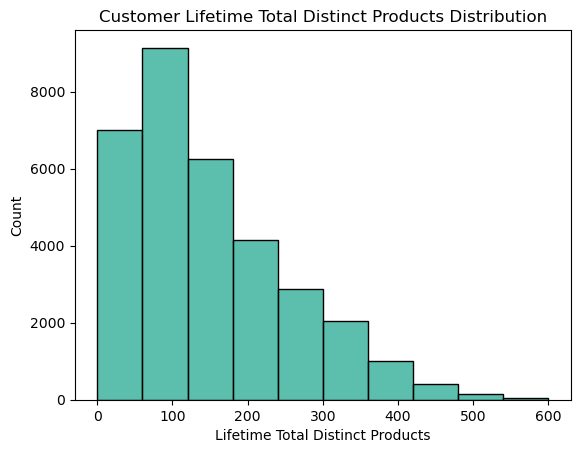

In [605]:
sns.histplot(data = cust_info['lifetime_total_distinct_products'], color = '#25a890', bins=10)
plt.title('Customer Lifetime Total Distinct Products Distribution')
plt.xlabel('Lifetime Total Distinct Products')
plt.ylabel('Count')
plt.show()

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;">Outliers</h3>

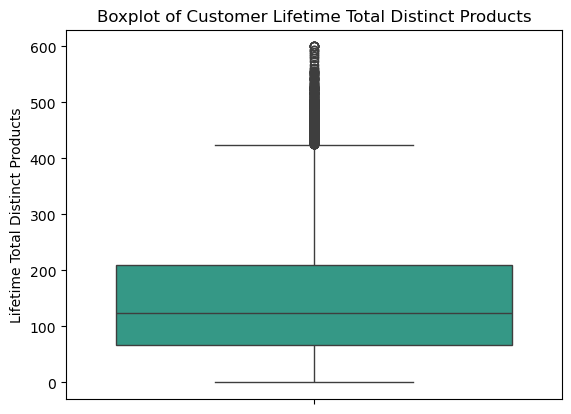

In [606]:
sns.boxplot(y=cust_info['lifetime_total_distinct_products'], color = '#25a890')
plt.title('Boxplot of Customer Lifetime Total Distinct Products')
plt.ylabel('Lifetime Total Distinct Products')
plt.show()

<h4 style="color: #25a890; margin-bottom: 5px; font-weight: 700;"><code style="color: #25a890;">percentage_of_products_bought_promotion</code></h4>


<p style="color: #25a890;">- Percentage/ratio</p>
<p style="color: #25a890;">- 330 (1%) of missing values</p>

In [607]:
variable = 'percentage_of_products_bought_promotion'
print("Missing Values: " + str(cust_info[variable].isnull().sum()))
percentage = cust_info[variable].isnull().sum() / len(cust_info) * 100
print("Missing Values Percentage: " + percentage.round(2).astype(str) + "%")

Missing Values: 330
Missing Values Percentage: 1.0%


In [608]:
cust_info['percentage_of_products_bought_promotion'].describe()

count    32708.000000
mean         0.318866
std          0.283638
min         -1.274940
25%          0.122359
50%          0.239449
75%          0.469390
max          1.000000
Name: percentage_of_products_bought_promotion, dtype: float64

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;"> Distribution</h3>

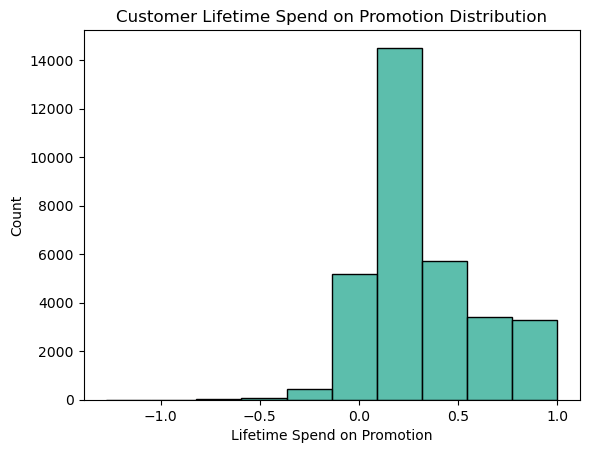

In [609]:
sns.histplot(data = cust_info['percentage_of_products_bought_promotion'], color = '#25a890', bins=10)
plt.title('Customer Lifetime Spend on Promotion Distribution')
plt.xlabel('Lifetime Spend on Promotion')
plt.ylabel('Count')
plt.show()

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;">Outliers</h3>

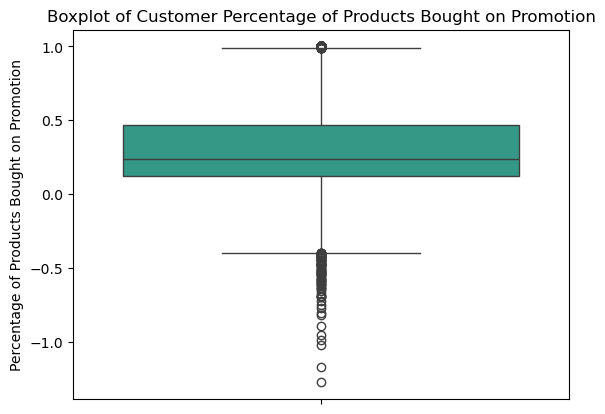

In [610]:
sns.boxplot(y=cust_info['percentage_of_products_bought_promotion'], color = '#25a890')
plt.title('Boxplot of Customer Percentage of Products Bought on Promotion')
plt.ylabel('Percentage of Products Bought on Promotion')
plt.show()

<h4 style="color: #25a890; margin-bottom: 5px; font-weight: 700;"><code style="color: #25a890;">year_first_transaction</code></h4>

<p style="color: #25a890;">- Year</p>
<p style="color: #25a890;">- No missing values</p>

In [611]:
variable = 'year_first_transaction'
print("Missing Values: " + str(cust_info[variable].isnull().sum()))
percentage = cust_info[variable].isnull().sum() / len(cust_info) * 100
print("Missing Values Percentage: " + percentage.round(2).astype(str) + "%")

Missing Values: 0
Missing Values Percentage: 0.0%


In [612]:
cust_info['year_first_transaction'].describe()

count    33038.000000
mean      2015.311853
std          5.032196
min       1993.000000
25%       2012.000000
50%       2015.000000
75%       2019.000000
max       2029.000000
Name: year_first_transaction, dtype: float64

In [613]:
cust_info['year_first_transaction'].head(10)

customer_id
3     2020.0
4     2013.0
5     2005.0
7     2021.0
8     2021.0
9     2011.0
10    2014.0
11    2017.0
12    2018.0
14    2017.0
Name: year_first_transaction, dtype: float64

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;"> Distribution</h3>

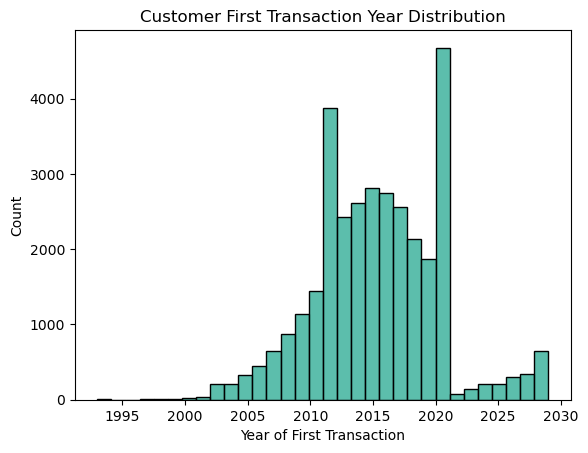

In [614]:
sns.histplot(data = cust_info['year_first_transaction'], color = '#25a890', bins=32)
plt.title('Customer First Transaction Year Distribution')
plt.xlabel('Year of First Transaction')
plt.ylabel('Count')
plt.show()

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;">Outliers</h3>

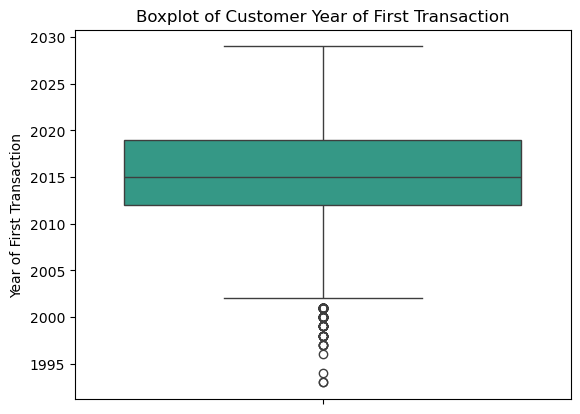

In [615]:
sns.boxplot(y=cust_info['year_first_transaction'], color = '#25a890')
plt.title('Boxplot of Customer Year of First Transaction')
plt.ylabel('Year of First Transaction')
plt.show()

<h4 style="color: #25a890; margin-bottom: 5px; font-weight: 700;"><code style="color: #25a890;">loyalty_card_number</code></h4>



<p style="color: #25a890;">- Binary variable - '1' has loyalty card, '0' doesn't have</p>
<p style="color: #25a890;">- 13106 (39,67%) of missing values</p>

In [616]:
variable = 'loyalty_card_number'
print("Missing Values: " + str(cust_info[variable].isnull().sum()))
percentage = cust_info[variable].isnull().sum() / len(cust_info) * 100
print("Missing Values Percentage: " + percentage.round(2).astype(str) + "%")

Missing Values: 13106
Missing Values Percentage: 39.67%


In [617]:
cust_info['loyalty_card_number'].describe()

count    19932.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
Name: loyalty_card_number, dtype: float64

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;"> Distribution</h3>

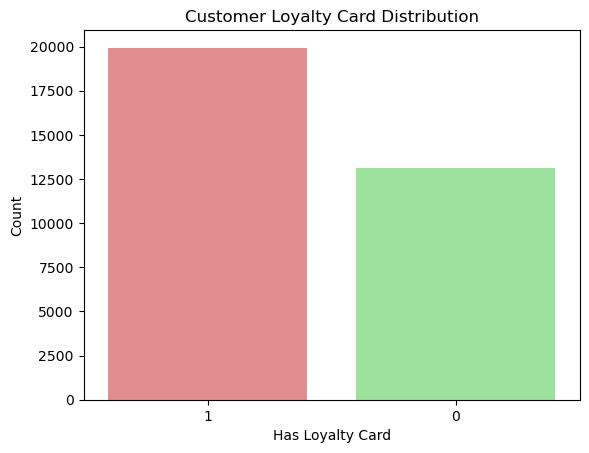

In [618]:
fill = cust_info['loyalty_card_number'].fillna(0).astype(int).astype(str)

palette2 = {'1': 'lightcoral', '0': 'lightgreen'}

sns.countplot(data=cust_info, x=fill, palette=palette2)
plt.title('Customer Loyalty Card Distribution')
plt.xlabel('Has Loyalty Card')
plt.ylabel('Count')
plt.show()

<h4 style="color: #25a890; margin-bottom: 5px; font-weight: 700;"><code style="color: #25a890;">latitude</code> and <code style="color: #25a890;">longitude</code></h4>



<p style="color: #25a890;">- Latitude and Longitude (geographical variables) - place where customer lives</p>
<p style="color: #25a890;">- No missing values</p>

In [619]:
variable = 'latitude'
print("Missing Values: " + str(cust_info[variable].isnull().sum()))
percentage = cust_info[variable].isnull().sum() / len(cust_info) * 100
print("Missing Values Percentage: " + percentage.round(2).astype(str) + "%")

Missing Values: 0
Missing Values Percentage: 0.0%


In [620]:
variable = 'longitude'
print("Missing Values: " + str(cust_info[variable].isnull().sum()))
percentage = cust_info[variable].isnull().sum() / len(cust_info) * 100
print("Missing Values Percentage: " + percentage.round(2).astype(str) + "%")

Missing Values: 0
Missing Values Percentage: 0.0%


<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;"> Geographic Distribution</h3>

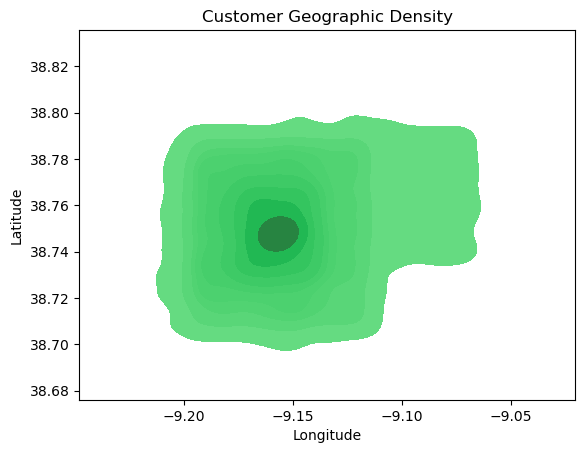

In [621]:
sns.kdeplot(data=cust_info, x='longitude', y='latitude', fill=True, color = "#0c7a33")
plt.title('Customer Geographic Density')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

<h2 style="color: #25a890; margin-bottom: 5px; font-weight: 700;">Correlation between variables</h2>

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;">Numerical vs Numerical</h3>

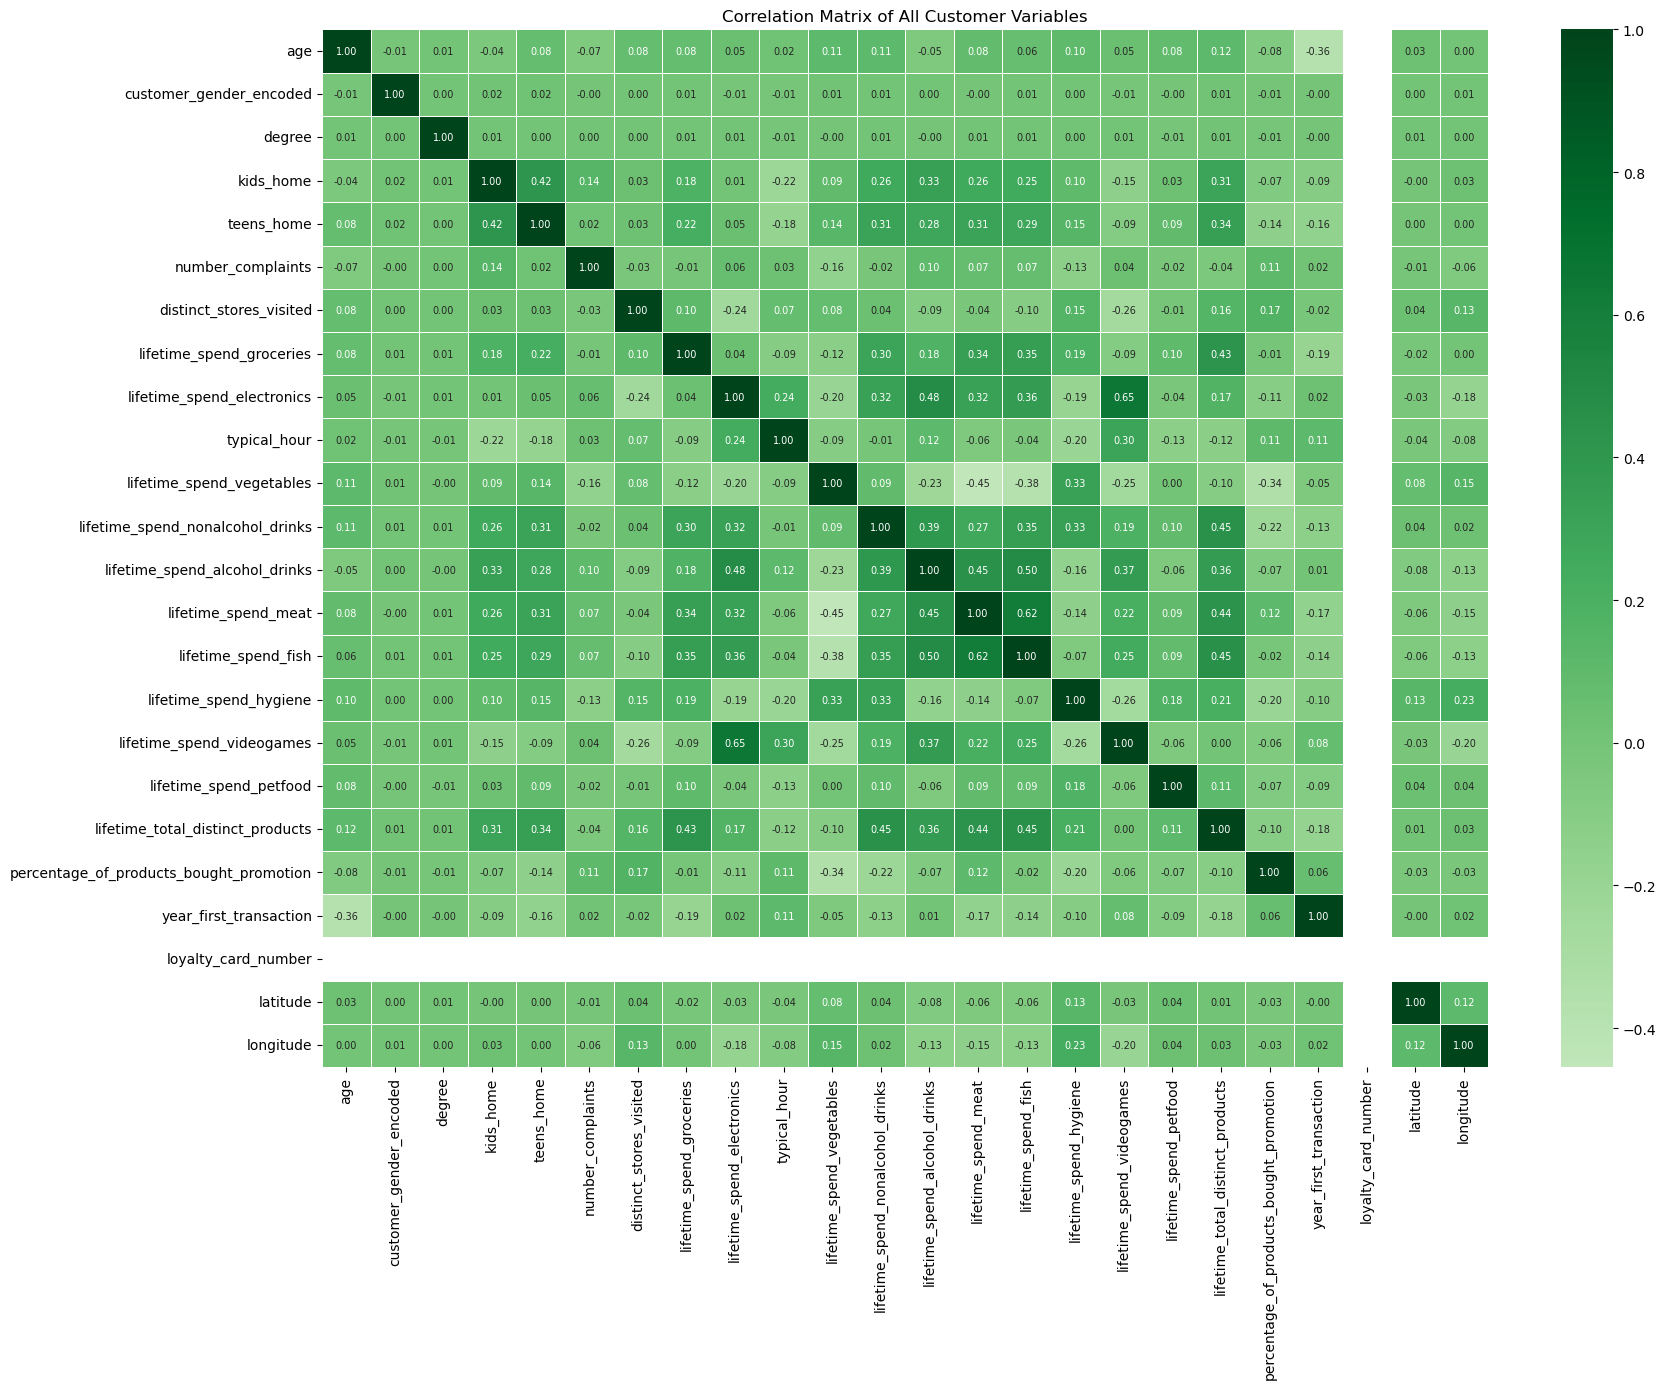

In [622]:
corr_df = cust_info.copy()

corr_df['age'] = pd.Timestamp.now().year - pd.to_datetime(corr_df['customer_birthdate']).dt.year

corr_df['degree'] = corr_df['customer_name'].str.extract(r'(PhD|Master|Bachelor|Dr)', expand=False)

le = LabelEncoder()
corr_df['customer_gender_encoded'] = le.fit_transform(corr_df['customer_gender'].astype(str))
corr_df['degree'] = le.fit_transform(corr_df['degree'].astype(str))

corr_cols = ['age', 'customer_gender_encoded', 'degree', 'kids_home', 'teens_home',
    'number_complaints', 'distinct_stores_visited', 'lifetime_spend_groceries',
    'lifetime_spend_electronics', 'typical_hour', 'lifetime_spend_vegetables',
    'lifetime_spend_nonalcohol_drinks', 'lifetime_spend_alcohol_drinks',
    'lifetime_spend_meat', 'lifetime_spend_fish', 'lifetime_spend_hygiene',
    'lifetime_spend_videogames', 'lifetime_spend_petfood',
    'lifetime_total_distinct_products', 'percentage_of_products_bought_promotion',
    'year_first_transaction', 'loyalty_card_number', 'latitude', 'longitude']

corr_matrix = corr_df[corr_cols].corr()

plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='Greens', center=0, linewidths=0.5, annot_kws={'size': 7})
plt.title('Correlation Matrix of All Customer Variables')
plt.tight_layout()
plt.show()

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;"> Numerical vs Categorical</h3>

In [623]:
categorical = ['customer_name', 'customer_gender', 'customer_birthdate', 'year_first_transaction', 'loyalty_card_number']

cust_info["has_loyalty_card"] = cust_info['loyalty_card_number'].fillna(0)
cust_info["has_loyalty_card"] = cust_info["has_loyalty_card"].astype(int)
categorical2 = ['customer_gender', 'has_loyalty_card']
numerical = [
    'kids_home',
    'teens_home',
    'number_complaints',
    'distinct_stores_visited',
    'lifetime_spend_groceries',
    'lifetime_spend_electronics',
    'typical_hour',
    'lifetime_spend_vegetables',
    'lifetime_spend_nonalcohol_drinks',
    'lifetime_spend_alcohol_drinks',
    'lifetime_spend_meat',
    'lifetime_spend_fish',
    'lifetime_spend_hygiene',
    'lifetime_spend_videogames',
    'lifetime_spend_petfood',
    'lifetime_total_distinct_products',
    'percentage_of_products_bought_promotion',
    'latitude',
    'longitude'
]

In [624]:
# ANOVA

to_corr = []

for cat in categorical2:
    for num in numerical:
        groups = [cust_info[num][cust_info[cat] == val].dropna() for val in cust_info[cat].dropna().unique()]

        if len(groups) < 2:
            continue

        f_stat, p_value = f_oneway(*groups)

        if p_value < 0.05:
            to_corr.append((cat, num))

if to_corr:
    print("\nSignificant associations found between:")
    for cat, num in to_corr:
        print(f"- {cat} and {num}")


Significant associations found between:
- customer_gender and kids_home
- customer_gender and teens_home
- customer_gender and lifetime_spend_vegetables
- customer_gender and lifetime_total_distinct_products
- has_loyalty_card and teens_home
- has_loyalty_card and number_complaints
- has_loyalty_card and distinct_stores_visited
- has_loyalty_card and lifetime_spend_groceries
- has_loyalty_card and lifetime_spend_electronics
- has_loyalty_card and typical_hour
- has_loyalty_card and lifetime_spend_vegetables
- has_loyalty_card and lifetime_spend_nonalcohol_drinks
- has_loyalty_card and lifetime_spend_alcohol_drinks
- has_loyalty_card and lifetime_spend_meat
- has_loyalty_card and lifetime_spend_fish
- has_loyalty_card and lifetime_spend_hygiene
- has_loyalty_card and lifetime_spend_videogames
- has_loyalty_card and lifetime_spend_petfood
- has_loyalty_card and lifetime_total_distinct_products
- has_loyalty_card and percentage_of_products_bought_promotion
- has_loyalty_card and longitud

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;">Categorical vs Categorical</h3>

In [625]:
MAX_UNIQUE_VALUES = 100  

safe_categorical = []
print("--- Checking Column Cardinality ---")
for col in categorical:
    unique_count = cust_info[col].nunique()
    if unique_count <= MAX_UNIQUE_VALUES:
        safe_categorical.append(col)
    else:
        print(f"Dropping '{col}' from analysis ({unique_count} unique values - too high!)")

print(f"\nProceeding with {len(safe_categorical)} safe categorical columns.\n")

to_corr_cat = []

print("--- Running Chi-Squared Tests ---")
for i, cat1 in enumerate(safe_categorical):
    for cat2 in safe_categorical[i + 1:]:  

        contingency_table = (cust_info.groupby([cat1, cat2], observed=True).size().unstack(fill_value=0))

        if contingency_table.empty or contingency_table.shape[0] < 2 or contingency_table.shape[1] < 2:
            continue

        chi2, p, dof, expected = chi2_contingency(contingency_table)
        print(f"{cat1} vs {cat2}: chi2={chi2:.3f}, p={p:.4f}")

        if p < 0.05:
            to_corr_cat.append((cat1, cat2))

print("\n--- Final Summary ---")
if to_corr_cat:
    print("Significant associations found between:")
    for cat1, cat2 in to_corr_cat:
        print(f"- {cat1} and {cat2}")
else:
    print("No statistically significant associations found.")

--- Checking Column Cardinality ---
Dropping 'customer_name' from analysis (32543 unique values - too high!)
Dropping 'customer_birthdate' from analysis (32852 unique values - too high!)

Proceeding with 3 safe categorical columns.

--- Running Chi-Squared Tests ---
customer_gender vs year_first_transaction: chi2=32.367, p=0.5959

--- Final Summary ---
No statistically significant associations found.
